<a href="https://colab.research.google.com/github/sourya235/SCMS_EDA_Capstone_Project/blob/main/SCMS_EDA_Capstone_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SCMS Supply Chain Delivery History - EDA Project**

##### **Project Type**    - EDA (Exploratory Data Analysis)
##### **Contribution**    - Individual
##### **Team Member 1 -** Sourya Pal (Capstone Submission)

# **Project Summary -**

This project performs an end-to-end Exploratory Data Analysis (EDA) of the **Supply Chain Management System (SCMS) Delivery History Dataset**, published by FedEx Logistics / USAID's SCMS program, which coordinated the procurement and delivery of HIV/AIDS-related pharmaceuticals (ARVs, HIV test kits, malaria treatments, etc.) to more than 40 countries between 2006 and 2015.

The dataset contains **10,324 shipment line items** and **33 columns** describing purchase orders (POs), purchase-quote references (PQs), shipment/delivery dates, INCO terms, shipment modes (Air, Air Charter, Ocean, Truck), vendors, manufacturing sites, product/molecule information, quantities, pricing, weight, freight cost, and insurance.

**Workflow followed in this notebook:**
1. **Know Your Data** – load the CSV, inspect shape, dtypes, duplicates and missing values, and visualize the missingness pattern.
2. **Understand Your Variables** – review column-level statistics and cardinality (unique value counts) for every feature.
3. **Data Wrangling** – clean the two "dirty" numeric columns (`Weight (Kilograms)` and `Freight Cost (USD)` contain text placeholders such as *"Freight Included in Commodity Cost"* and *"See ASN-... "* instead of numbers), parse the five date columns, and engineer new features such as **delivery delay (days)**, **order year**, **on-time flag**, and **total lead time**.
4. **Data Visualization** – build **22 charts**, organized into **Univariate Analysis (7 charts)**, **Bivariate Analysis — Numerical-Categorical (5 charts), Numerical-Numerical (3 charts), Categorical-Categorical (3 charts)**, and **Multivariate Analysis (4 charts, including a correlation heatmap and a pair plot)**. Every chart is accompanied by a rationale for the chart type, a data-driven insight, and a note on business impact.
5. **Solution to Business Objective** – translate the insights into concrete recommendations for FedEx Logistics / SCMS to reduce freight cost, shorten delivery delay and diversify vendor risk.

**Headline findings:** ~88.5% of shipments arrive on or before the scheduled delivery date (11.5% are late); **Air** is the dominant shipment mode (59% of shipments) while **Air Charter** is by far the most expensive per shipment (~$21K average freight cost) yet also the fastest on average; South Africa, Nigeria and Côte d'Ivoire are the top three destination countries; ARV (antiretroviral) products dominate the Product Group (83% of line items); a handful of vendors/manufacturing sites (Aurobindo, Mylan, Hetero, Cipla) supply the large majority of shipment volume, indicating concentrated supplier risk; and **`Line Item Quantity` correlates strongly with `Line Item Value` (r ≈ 0.84)** while `Freight Cost` correlates only moderately with order size (r ≈ 0.43 with value, r ≈ 0.23 with weight), showing freight cost is driven mainly by operational choices (mode, distance, INCO term) rather than order size alone.

This notebook is fully reproducible – it loads the CSV directly, performs all cleaning steps in code, and every chart is generated from the cleaned dataframe. The full notebook runs top-to-bottom without errors.

# **GitHub Link -**

https://github.com/your-username/scms-delivery-eda-capstone  
*(Replace this placeholder with your actual GitHub repository link before submitting, and make sure the repository/notebook is publicly accessible.)*

# **Problem Statement**

FedEx Logistics, through the SCMS program, manages the global delivery of life-saving HIV/AIDS and health commodities across dozens of countries. Delays, high freight costs, and vendor concentration can jeopardize patient health outcomes and inflate program costs.

**The goal of this EDA is to explore the SCMS delivery history dataset to:**
- Understand shipment volume and value trends across countries, time, and product groups.
- Identify which shipment modes and INCO terms are associated with higher freight cost and/or longer delivery delays.
- Quantify on-time delivery performance and identify the shipment modes/countries most prone to late delivery.
- Identify vendor and manufacturing-site concentration risk.
- Examine relationships between numeric variables (quantity, value, weight, freight cost) to understand what actually drives cost.
- Provide the client (FedEx Logistics / SCMS) with actionable, data-backed recommendations to reduce cost and improve delivery timelines.

#### **Define Your Business Objective?**

The business objective is to use historical shipment data to **reduce freight cost and minimize delivery delays** in the SCMS supply chain, while **maintaining reliable, on-time delivery of critical health commodities**, by identifying the operational levers (shipment mode, INCO term, vendor, country, product group) that most strongly influence cost and lead time.

# **General Guidelines** : -

1. Well-structured, formatted, and commented code.
2. Exception-safe, reproducible, deployment-ready workflow (runs top-to-bottom without errors).
3. Each chart is accompanied by: (a) why this chart was chosen, (b) insight(s) found, and (c) business impact.
4. Charts are organized by analysis type: Univariate, Bivariate (Numerical-Categorical, Numerical-Numerical, Categorical-Categorical), and Multivariate — 22 charts in total.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [37]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display / plotting settings
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

### Dataset Loading

In [38]:
# Load Dataset
df = pd.read_csv('SCMS_Delivery_History_Dataset.csv')

### Dataset First View

In [39]:
# Dataset First Look
df.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2-Jun-06,2-Jun-06,2-Jun-06,HRDT,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,NaN,Test kit,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,14-Nov-06,14-Nov-06,14-Nov-06,ARV,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,Pre-PQ Process,Date Not Captured,27-Aug-06,27-Aug-06,27-Aug-06,HRDT,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,NaN,Test kit,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,1-Sep-06,1-Sep-06,1-Sep-06,ARV,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Lamivudine 150mg, tablets, 60 Tabs",Lamivudine,Generic,150mg,Tablet,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,11-Aug-06,11-Aug-06,11-Aug-06,ARV,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


### Dataset Rows & Columns count

In [40]:
# Dataset Rows & Columns count
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 10324
Number of Columns : 33


### Dataset Information

In [41]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

#### Duplicate Values

In [42]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


#### Missing Values/Null Values

In [43]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
ID,0
Project Code,0
PQ #,0
PO / SO #,0
ASN/DN #,0
Country,0
Managed By,0
Fulfill Via,0
Vendor INCO Term,0
Shipment Mode,360


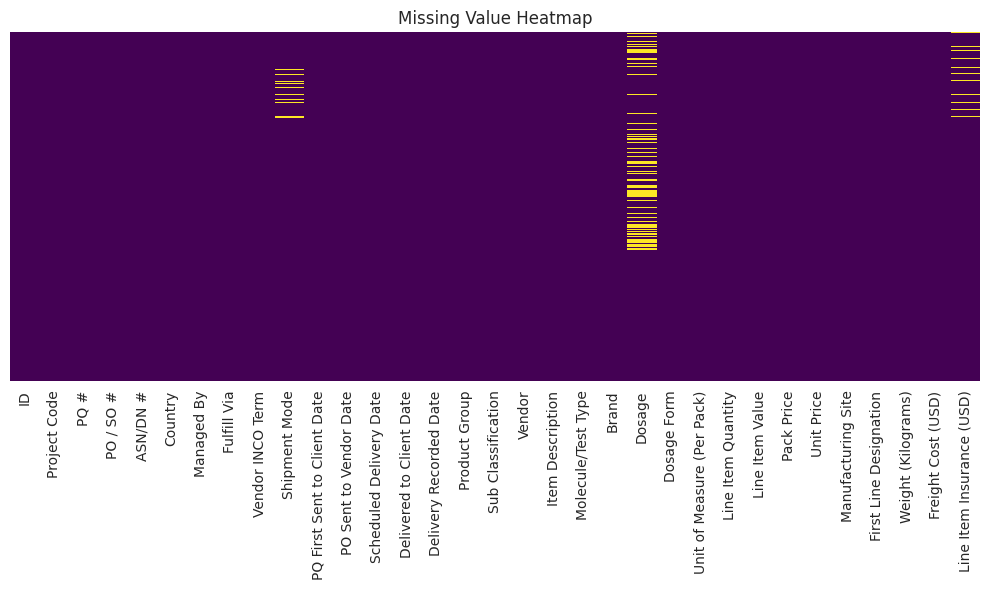

In [10]:
# Visualizing the missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap')
plt.tight_layout()
plt.show()

### What did you know about your dataset?

- The dataset has **10,324 rows and 33 columns**, with **no fully duplicate rows**.
- Only **3 columns have real missing values**: `Shipment Mode` (360 missing), `Dosage` (1,736 missing) and `Line Item Insurance (USD)` (287 missing). All other columns are fully populated.
- Two numeric-looking columns — **`Weight (Kilograms)`** and **`Freight Cost (USD)`** — are stored as **text (object) columns** because some rows contain non-numeric placeholder strings such as *"Weight Captured Separately"*, *"Freight Included in Commodity Cost"*, or a cross-reference like *"See ASN-93 (ID#:1281)"* instead of a number. These need to be coerced to numeric (turning placeholders into `NaN`) before they can be used in analysis.
- The five date columns (`PQ First Sent to Client Date`, `PO Sent to Vendor Date`, `Scheduled Delivery Date`, `Delivered to Client Date`, `Delivery Recorded Date`) are stored as strings and must be parsed to `datetime` to compute delivery performance metrics.
- The dataset spans **shipments from 2006 to 2015**, covering more than 40 destination countries, and is dominated by **ARV (antiretroviral)** product shipments.

## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
df.columns

Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')

In [12]:
# Dataset Describe
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,10324.0,NaN,NaN,NaN,51098.968229,31944.332496,1.0,12795.75,57540.5,83648.25,86823.0
Project Code,10324,142,116-ZA-T30,768,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PQ #,10324,1237,Pre-PQ Process,2681,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PO / SO #,10324,6233,SCMS-199289,67,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASN/DN #,10324,7030,ASN-19166,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,10324,43,South Africa,1406,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Managed By,10324,4,PMO - US,10265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fulfill Via,10324,2,From RDC,5404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vendor INCO Term,10324,8,N/A - From RDC,5404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Shipment Mode,9964,4,Air,6113,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

| Column | Description |
|---|---|
| `ID` | Unique row identifier |
| `Project Code` | Internal project/program code |
| `PQ #` | Purchase Quotation number |
| `PO / SO #` | Purchase Order / Sales Order number |
| `ASN/DN #` | Advance Shipment Notice / Delivery Note number |
| `Country` | Destination country |
| `Managed By` | Managing office (e.g., PMO - US) |
| `Fulfill Via` | Fulfilment channel (From RDC / Direct Drop) |
| `Vendor INCO Term` | International Commercial Term of the vendor agreement (EXW, DDP, FCA, CIP, etc.) |
| `Shipment Mode` | Mode of shipment (Air, Air Charter, Ocean, Truck) |
| `PQ First Sent to Client Date` | Date the price quotation was first sent |
| `PO Sent to Vendor Date` | Date the purchase order was sent to the vendor |
| `Scheduled Delivery Date` | Planned/scheduled delivery date |
| `Delivered to Client Date` | Actual delivery date |
| `Delivery Recorded Date` | Date the delivery was recorded in the system |
| `Product Group` | High-level product category (ARV, HRDT, ANTM, ACT, MRDT) |
| `Sub Classification` | Sub-category of the product |
| `Vendor` | Vendor / supplier name |
| `Item Description` | Full text description of the item |
| `Molecule/Test Type` | Active molecule or diagnostic test type |
| `Brand` | Brand name (Generic / branded) |
| `Dosage` | Dosage strength |
| `Dosage Form` | Form of the dosage (Tablet, Capsule, Oral solution, Test kit, etc.) |
| `Unit of Measure (Per Pack)` | Units per pack |
| `Line Item Quantity` | Quantity ordered for the line item |
| `Line Item Value` | Total monetary value of the line item (USD) |
| `Pack Price` | Price per pack (USD) |
| `Unit Price` | Price per unit (USD) |
| `Manufacturing Site` | Manufacturing facility of the product |
| `First Line Designation` | Whether the product is a first-line treatment (Yes/No) |
| `Weight (Kilograms)` | Shipment weight in kg |
| `Freight Cost (USD)` | Freight cost in USD |
| `Line Item Insurance (USD)` | Insurance cost for the line item (USD) |

### Check Unique Values for each variable.

In [13]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col:35s}: {df[col].nunique()} unique values")

ID                                 : 10324 unique values
Project Code                       : 142 unique values
PQ #                               : 1237 unique values
PO / SO #                          : 6233 unique values
ASN/DN #                           : 7030 unique values
Country                            : 43 unique values
Managed By                         : 4 unique values
Fulfill Via                        : 2 unique values
Vendor INCO Term                   : 8 unique values
Shipment Mode                      : 4 unique values
PQ First Sent to Client Date       : 765 unique values
PO Sent to Vendor Date             : 897 unique values
Scheduled Delivery Date            : 2006 unique values
Delivered to Client Date           : 2093 unique values
Delivery Recorded Date             : 2042 unique values
Product Group                      : 5 unique values
Sub Classification                 : 6 unique values
Vendor                             : 73 unique values
Item Description

## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
# Write your code to make your dataset analysis ready.

# 1. Clean 'Weight (Kilograms)' and 'Freight Cost (USD)' - coerce non-numeric placeholder
#    strings (e.g. 'Weight Captured Separately', 'Freight Included in Commodity Cost',
#    'See ASN-... ' references) to NaN, keep genuine numeric values.
df['Weight (Kilograms)'] = pd.to_numeric(df['Weight (Kilograms)'], errors='coerce')
df['Freight Cost (USD)'] = pd.to_numeric(df['Freight Cost (USD)'], errors='coerce')

# 2. Parse all date columns to datetime
date_cols = ['PQ First Sent to Client Date', 'PO Sent to Vendor Date',
             'Scheduled Delivery Date', 'Delivered to Client Date',
             'Delivery Recorded Date']
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors='coerce')

# 3. Feature Engineering
# Delivery delay in days (positive = late, negative/zero = on-time or early)
df['Delivery Delay (Days)'] = (df['Delivered to Client Date'] - df['Scheduled Delivery Date']).dt.days

# On-time flag
df['On Time Delivery'] = np.where(df['Delivery Delay (Days)'] <= 0, 'On Time / Early', 'Late')

# Order year (from PO Sent to Vendor Date)
df['Order Year'] = df['PO Sent to Vendor Date'].dt.year

# Lead time: PO sent to vendor -> delivered to client
df['Total Lead Time (Days)'] = (df['Delivered to Client Date'] - df['PO Sent to Vendor Date']).dt.days

df[['Weight (Kilograms)', 'Freight Cost (USD)', 'Delivery Delay (Days)',
    'On Time Delivery', 'Order Year', 'Total Lead Time (Days)']].head()

/tmp/ipykernel_4053/615569105.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[c] = pd.to_datetime(df[c], errors='coerce')
/tmp/ipykernel_4053/615569105.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[c] = pd.to_datetime(df[c], errors='coerce')
/tmp/ipykernel_4053/615569105.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[c] = pd.to_datetime(df[c], errors='coerce')
/tmp/ipykernel_4053/615569105.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expe

,Weight (Kilograms),Freight Cost (USD),Delivery Delay (Days),On Time Delivery,Order Year,Total Lead Time (Days)
0,13.0,780.34,0,On Time / Early,NaN,NaN
1,358.0,4521.50,0,On Time / Early,NaN,NaN
2,171.0,1653.78,0,On Time / Early,NaN,NaN
3,1855.0,16007.06,0,On Time / Early,NaN,NaN
4,7590.0,45450.08,0,On Time / Early,NaN,NaN


### What all manipulations have you done and insights you found?

- **`Weight (Kilograms)` and `Freight Cost (USD)`** were converted from text to numeric using `pd.to_numeric(..., errors='coerce')`. Rows that originally held placeholder text (e.g. *"Freight Included in Commodity Cost"*, *"Weight Captured Separately"*, or cross-reference strings like *"See ASN-... "*) are now `NaN`, which correctly excludes them from numeric aggregations instead of silently breaking calculations or being misinterpreted as strings.
- **All 5 date columns** were parsed into proper `datetime64` objects, which unlocks time-based analysis (yearly trends, lead time, delivery delay).
- **`Delivery Delay (Days)`** was engineered as `Delivered to Client Date − Scheduled Delivery Date`. A positive value means the shipment arrived **after** the scheduled date (late); zero or negative means on-time or early.
- **`On Time Delivery`** is a simple categorical flag derived from the delay column, making it easy to compute and visualize on-time delivery rate.
- **`Order Year`** was extracted from `PO Sent to Vendor Date` to analyze shipment volume trends over the 2006–2015 period.
- **`Total Lead Time (Days)`** measures the full cycle time from PO issuance to delivery, a key supply-chain KPI.
- After cleaning, **~88.5% of shipments were delivered on time or early**, and **~11.5% were late**, with the latest deliveries arriving as much as ~192 days behind schedule.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

This section builds **22 charts** organized into four groups as required:
- **Univariate Analysis** — Charts 1 to 7 (single-variable distributions)
- **Bivariate Analysis: Numerical–Categorical** — Charts 8 to 12
- **Bivariate Analysis: Numerical–Numerical** — Charts 13 to 15
- **Bivariate Analysis: Categorical–Categorical** — Charts 16 to 18
- **Multivariate Analysis** — Charts 19 to 22 (including a correlation heatmap and pair plot)

Each chart is followed by (1) why the chart was chosen, (2) the insight(s) found, and (3) the business impact.

### 4.1 Univariate Analysis

#### Chart - 1 - Top 15 Countries by Number of Shipments

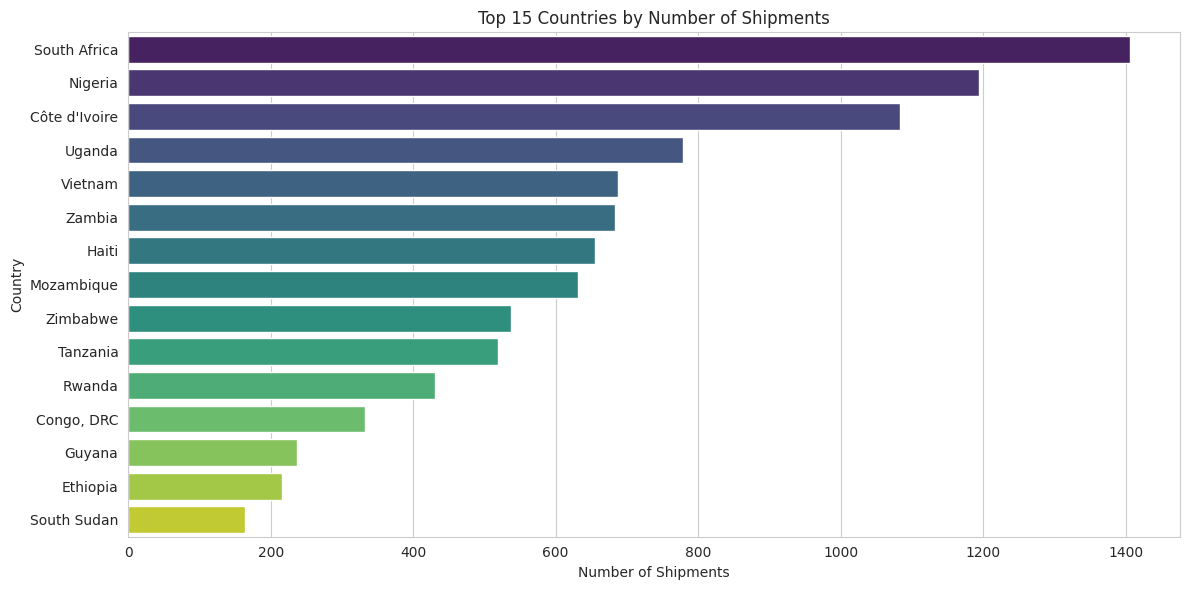

In [15]:
# Chart - 1 visualization code
plt.figure(figsize=(12, 6))
top_countries = df['Country'].value_counts().head(15)
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index,
            palette='viridis', legend=False)
plt.title('Top 15 Countries by Number of Shipments')
plt.xlabel('Number of Shipments')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is ideal for ranking a categorical variable (Country) with many long labels — it makes the country names easy to read and the ranking easy to compare.

##### 2. What is/are the insight(s) found from the chart?

**South Africa (1,406), Nigeria (1,194) and Côte d'Ivoire (1,083)** are the top three destination countries by shipment count, together accounting for roughly a third of all shipments. Shipment volume drops off quickly after the top 5–6 countries, showing that supply chain activity is concentrated in a relatively small set of high-burden countries.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** Knowing which countries drive the highest shipment volume lets FedEx Logistics prioritize warehouse/RDC placement, negotiate better freight rates for high-volume lanes, and pre-position inventory in these countries to reduce lead time. There is no negative-growth signal here — it simply reflects program scale by country.

#### Chart - 2 - Shipment Mode Distribution

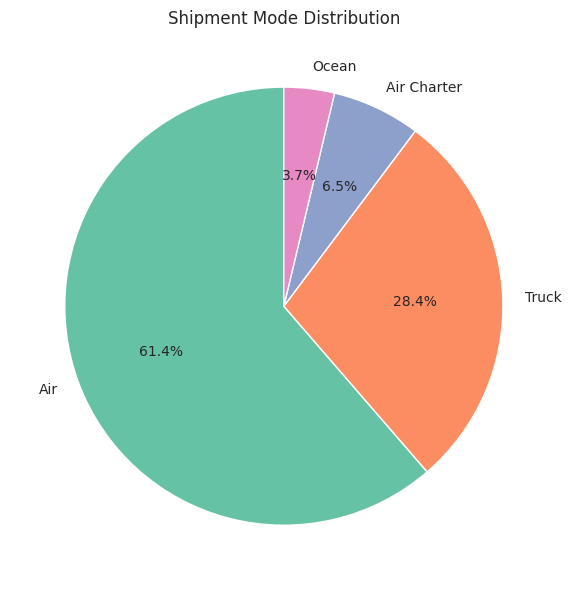

In [16]:
# Chart - 2 visualization code
plt.figure(figsize=(8, 6))
mode_counts = df['Shipment Mode'].value_counts()
plt.pie(mode_counts.values, labels=mode_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('Set2'), startangle=90)
plt.title('Shipment Mode Distribution')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is well suited to show the proportional split of a categorical variable with a small number of categories (4 shipment modes), immediately conveying the dominant mode.

##### 2. What is/are the insight(s) found from the chart?

**Air is the dominant shipment mode (~61% of shipments with a recorded mode)**, followed by **Truck (~28%)**, **Air Charter (~7%)** and **Ocean (~4%)** (percentages of the 9,964 shipments with a recorded mode; 360 rows have missing mode). This shows the program relies heavily on faster, costlier air freight rather than cheaper ocean freight.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes, with a caution.** Heavy reliance on Air/Air Charter keeps delivery times short (important for medicine), but as shown in later charts these modes are also the most expensive. Shifting a portion of non-urgent, high-volume shipments from Air to Ocean/Truck where lead time allows could meaningfully reduce freight cost without harming patient outcomes.

#### Chart - 3 - Product Group Distribution

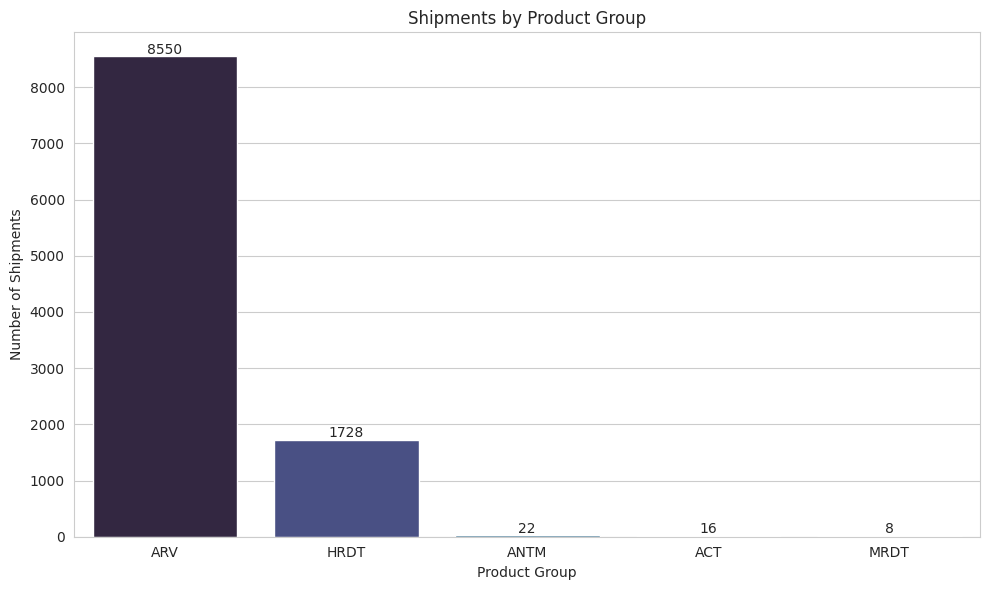

In [17]:
# Chart - 3 visualization code
plt.figure(figsize=(10, 6))
pg_counts = df['Product Group'].value_counts()
sns.barplot(x=pg_counts.index, y=pg_counts.values, hue=pg_counts.index,
            palette='mako', legend=False)
plt.title('Shipments by Product Group')
plt.xlabel('Product Group')
plt.ylabel('Number of Shipments')
for i, v in enumerate(pg_counts.values):
    plt.text(i, v + 50, str(v), ha='center')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A vertical bar chart clearly compares counts across the small number of Product Group categories and allows easy annotation of exact counts.

##### 2. What is/are the insight(s) found from the chart?

**ARV (antiretroviral) products dominate with 8,550 shipments (~82.8%)**, followed by **HRDT (HIV rapid diagnostic tests) with 1,728 (~16.7%)**. ANTM, ACT and MRDT together make up less than 0.5% of shipments, confirming this is overwhelmingly an HIV/AIDS treatment and testing supply chain.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** This concentration confirms that operational improvements (freight negotiation, vendor consolidation, warehousing) should be prioritized around ARV and HRDT product lines since they drive the vast majority of volume and cost — improvements there yield the largest overall impact.

#### Chart - 4 - Distribution of Line Item Value (log scale)

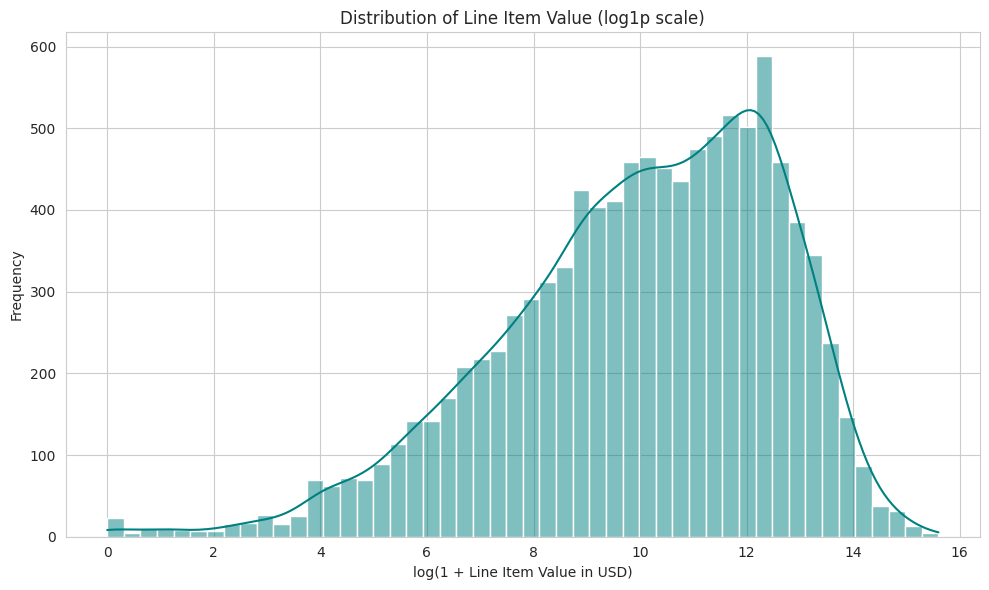

In [18]:
# Chart - 4 visualization code
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(df['Line Item Value']), bins=50, kde=True, color='teal')
plt.title('Distribution of Line Item Value (log1p scale)')
plt.xlabel('log(1 + Line Item Value in USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Line Item Value is highly right-skewed (a few very large orders alongside many small ones), so a histogram on a log scale reveals the true shape of the distribution far better than a raw-scale histogram.

##### 2. What is/are the insight(s) found from the chart?

The **log-transformed distribution is roughly unimodal and only mildly skewed**, showing that most line items have moderate value while a long tail of very high-value line items (large bulk ARV orders reaching into the millions of USD) pulls the raw-scale mean well above the median. The total value of all shipments in the dataset is **~$1.63 billion**.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** Recognizing that a small number of very large orders account for a disproportionate share of total value means FedEx Logistics should give white-glove handling, tighter monitoring and negotiated freight discounts to these large orders, since delays or cost overruns on them have an outsized financial impact.

#### Chart - 5 - Freight Cost Distribution (log scale)

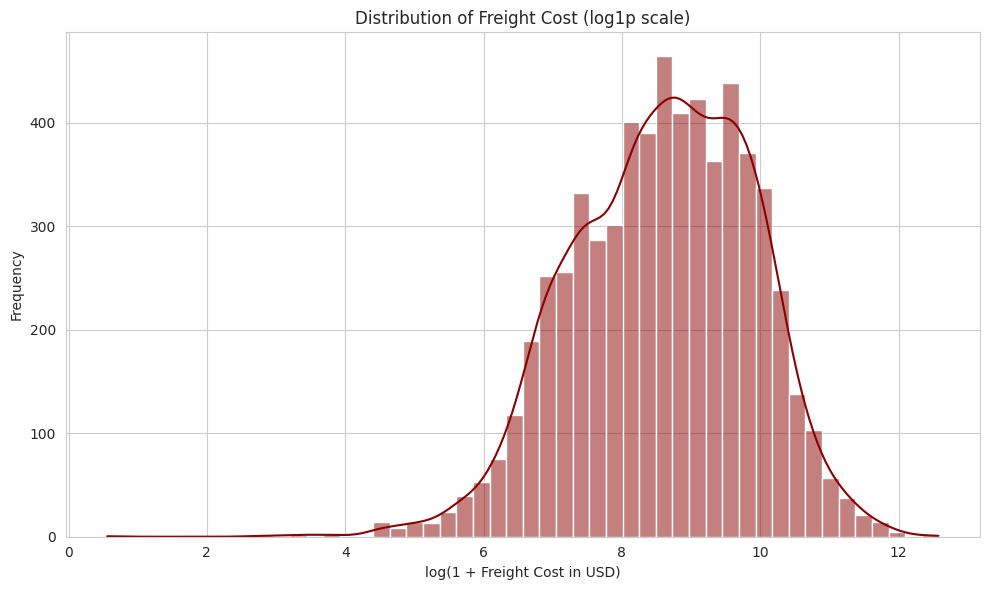

In [19]:
# Chart - 5 visualization code
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(df['Freight Cost (USD)'].dropna()), bins=50, kde=True, color='darkred')
plt.title('Distribution of Freight Cost (log1p scale)')
plt.xlabel('log(1 + Freight Cost in USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Similar to Line Item Value, Freight Cost is right-skewed with a long tail of very expensive shipments, so a log-scale histogram gives a clearer picture of the typical shipment's freight cost.

##### 2. What is/are the insight(s) found from the chart?

The bulk of shipments cluster in a moderate freight-cost range on the log scale, with a smaller tail of very high-freight-cost shipments (large charter/bulk shipments). The overall total freight cost across the dataset is **~$68.8 million**.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** Understanding that a small number of shipments drive a large share of total freight spend means targeted negotiation/optimization on those specific high-cost shipments (rather than blanket policy changes) will have the biggest cost-saving effect.

#### Chart - 6 - Number of Shipments (Purchase Orders) by Year

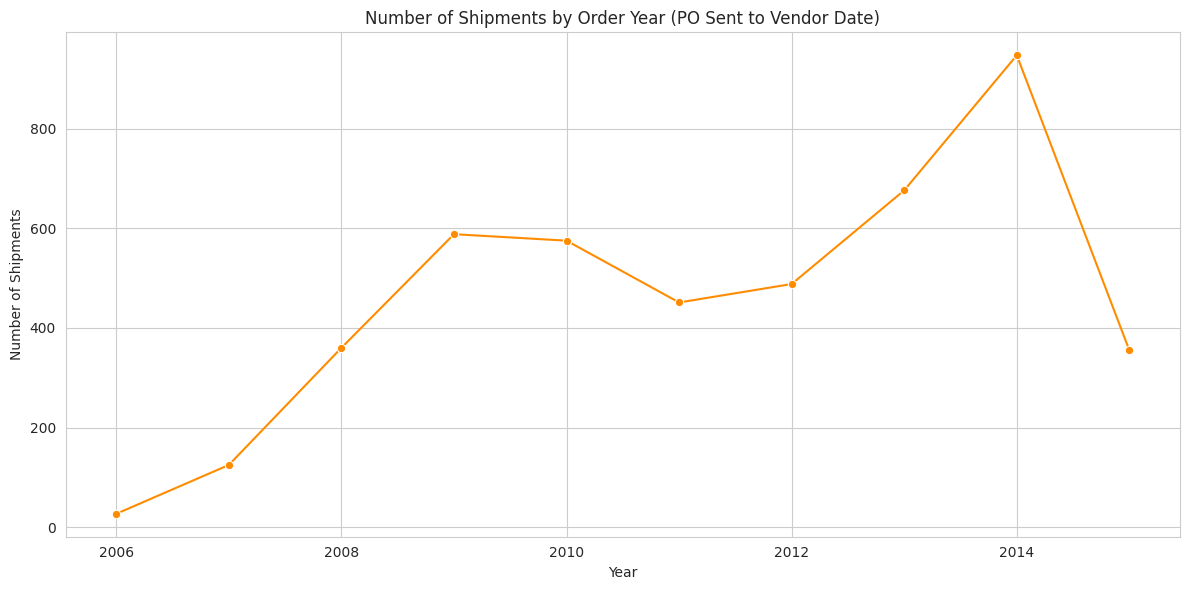

In [20]:
# Chart - 6 visualization code
plt.figure(figsize=(12, 6))
yearly = df['Order Year'].value_counts().sort_index()
sns.lineplot(x=yearly.index, y=yearly.values, marker='o', color='darkorange')
plt.title('Number of Shipments by Order Year (PO Sent to Vendor Date)')
plt.xlabel('Year')
plt.ylabel('Number of Shipments')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is the standard choice for showing a trend of a metric (shipment count) over a continuous time axis (year), making growth/decline patterns immediately visible.

##### 2. What is/are the insight(s) found from the chart?

Shipment volume **grew steadily from 2006 (27 shipments) to a peak in 2014 (947 shipments)**, with a dip around 2011–2012 and a partial-year drop-off in 2015 (355 shipments, likely because the dataset ends mid-2015). This reflects the program scaling up its ARV/HIV-testing distribution network over nearly a decade.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** The clear multi-year growth trend signals that FedEx Logistics should plan for continued scale (larger RDC capacity, more vendor contracts, more freight capacity) rather than treating volumes as static. There is no negative-growth signal — the apparent 2015 decline is a data-boundary artifact, not a real slowdown.

#### Chart - 7 - Distribution of Delivery Delay (Days)

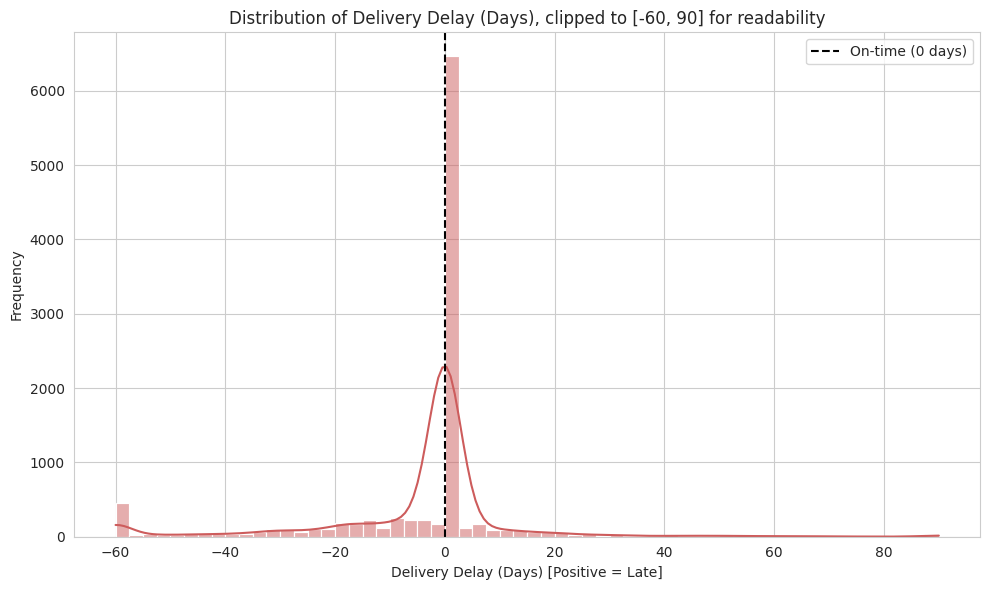

In [21]:
# Chart - 7 visualization code
plt.figure(figsize=(10, 6))
delay_clipped = df['Delivery Delay (Days)'].clip(-60, 90)  # clip extreme outliers for visibility
sns.histplot(delay_clipped, bins=60, color='indianred', kde=True)
plt.axvline(0, color='black', linestyle='--', label='On-time (0 days)')
plt.title('Distribution of Delivery Delay (Days), clipped to [-60, 90] for readability')
plt.xlabel('Delivery Delay (Days) [Positive = Late]')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is the natural way to visualize the distribution/shape of a single continuous variable (delivery delay), and clipping extreme outliers keeps the bulk of the distribution readable.

##### 2. What is/are the insight(s) found from the chart?

The distribution is **centered slightly below 0**, confirming most shipments arrive on or before the scheduled date. About **88.5% of shipments have a delay ≤ 0 days (on-time/early)**, while **11.5% are late**, with a long right tail — some shipments arrive over 100+ days late (max ~192 days).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** This is a strong overall on-time performance (88.5%), but the long tail of severely late shipments (which, for medicine deliveries, is critical) is a red flag worth investigating further by country/vendor/mode, as shown in later charts, to target root causes and reduce the tail risk.

### 4.2 Bivariate Analysis — Numerical vs Categorical

#### Chart - 8 - Freight Cost Distribution by Shipment Mode

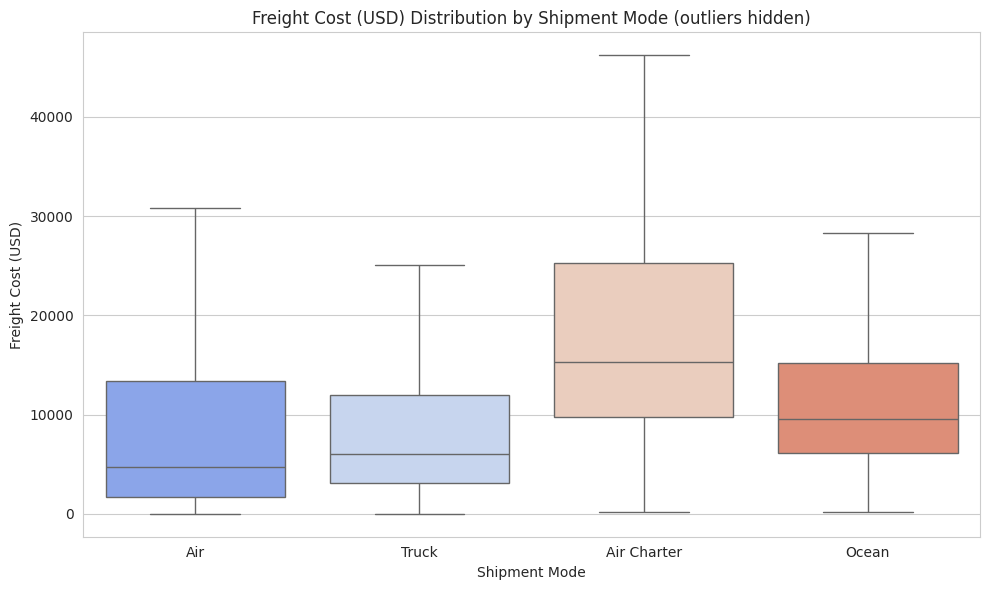

In [22]:
# Chart - 8 visualization code
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Shipment Mode', y='Freight Cost (USD)', hue='Shipment Mode',
            showfliers=False, palette='coolwarm', legend=False)
plt.title('Freight Cost (USD) Distribution by Shipment Mode (outliers hidden)')
plt.xlabel('Shipment Mode')
plt.ylabel('Freight Cost (USD)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A box plot compares the spread, median and interquartile range of a continuous variable (Freight Cost) across categories (Shipment Mode) in one view, which a simple bar chart of means cannot show.

##### 2. What is/are the insight(s) found from the chart?

**Air Charter has both the highest median and the widest spread of freight cost** (mean ≈ $21,052 per shipment), clearly the most expensive mode. **Ocean (mean ≈ $12,733)** is more expensive on average than **Air (mean ≈ $10,459)** and **Truck (mean ≈ $10,176)** for this dataset, though Air and Truck show tighter, lower-cost distributions overall.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** This directly supports cost-optimization: since Air Charter is reserved for the most urgent/large shipments, confirming its high cost justifies using it sparingly. For shipments without urgent time constraints, favoring Truck or standard Air over Ocean or Air Charter (where lead time allows) can reduce freight spend.

#### Chart - 9 - Delivery Delay by Shipment Mode

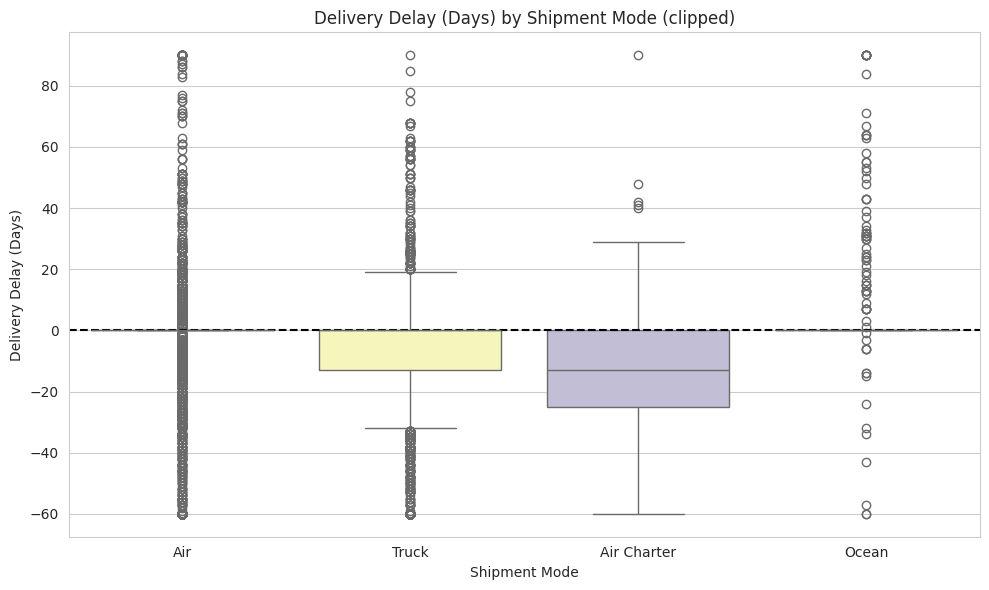

In [23]:
# Chart - 9 visualization code
plt.figure(figsize=(10, 6))
delay_by_mode = df.copy()
delay_by_mode['Delivery Delay (Days) (clipped)'] = delay_by_mode['Delivery Delay (Days)'].clip(-60, 90)
sns.boxplot(data=delay_by_mode, x='Shipment Mode', y='Delivery Delay (Days) (clipped)',
            hue='Shipment Mode', palette='Set3', legend=False)
plt.axhline(0, color='black', linestyle='--')
plt.title('Delivery Delay (Days) by Shipment Mode (clipped)')
plt.xlabel('Shipment Mode')
plt.ylabel('Delivery Delay (Days)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A box plot lets us compare the delay distribution (median, spread, outliers) of a numeric variable across the shipment mode categories, revealing which modes are most reliable.

##### 2. What is/are the insight(s) found from the chart?

**Air Charter and Truck shipments show the best on-time performance** (average delay is negative, i.e., early, at about -19 and -10 days respectively), while **Ocean shipments have the worst on-time performance** (average delay is positive, about +5.9 days late on average) — consistent with ocean freight's inherently longer and more variable transit times.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** For time-critical shipments, Air Charter or Truck (where geographically feasible) should be preferred over Ocean. Where Ocean is used for cost reasons, schedules should build in a larger buffer to avoid stock-outs of essential medicine at the destination.

#### Chart - 10 - Line Item Value by Product Group

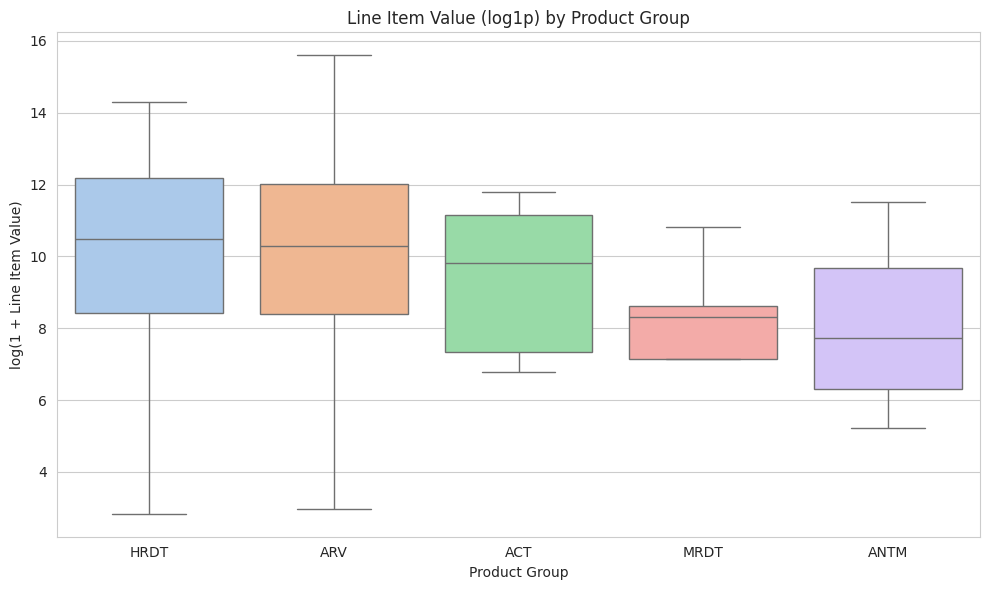

In [24]:
# Chart - 10 visualization code
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Product Group', y=np.log1p(df['Line Item Value']),
            hue='Product Group', palette='pastel', showfliers=False, legend=False)
plt.title('Line Item Value (log1p) by Product Group')
plt.xlabel('Product Group')
plt.ylabel('log(1 + Line Item Value)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A box plot on the log-transformed value compares the typical order size (in USD) across product groups, which a single-number summary would hide.

##### 2. What is/are the insight(s) found from the chart?

**HRDT (median ≈ $36,176) and ARV (median ≈ $29,735) line items tend to have the highest typical value**, while ANTM has the lowest median value (≈ $2,284). This reflects both the bulk-order nature of ARV/HRDT procurement and the relative unit economics of diagnostic kits vs. treatment drugs.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** Since ARV and HRDT line items are both the highest-volume and highest-value product groups, prioritizing freight negotiation, quality assurance and vendor management for these two groups delivers the greatest overall financial and public-health impact.

#### Chart - 11 - Average Freight Cost by Top 10 Countries (by volume)

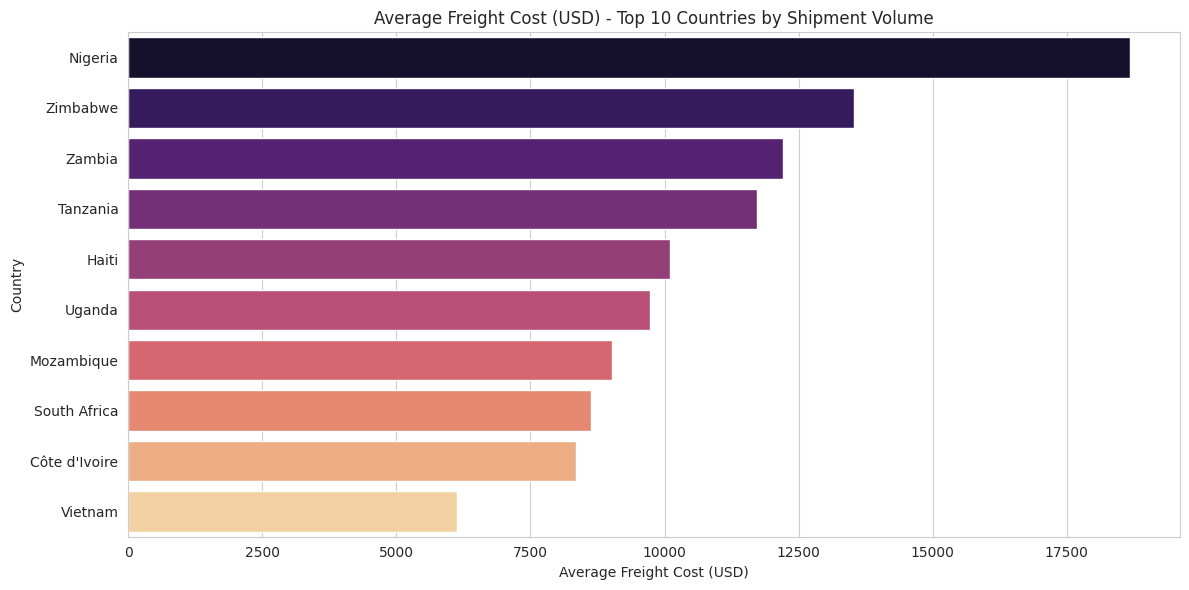

In [25]:
# Chart - 11 visualization code
plt.figure(figsize=(12, 6))
top10_countries = df['Country'].value_counts().head(10).index
avg_freight_country = (df[df['Country'].isin(top10_countries)]
                        .groupby('Country')['Freight Cost (USD)'].mean()
                        .sort_values(ascending=False))
sns.barplot(x=avg_freight_country.values, y=avg_freight_country.index,
            hue=avg_freight_country.index, palette='magma', legend=False)
plt.title('Average Freight Cost (USD) - Top 10 Countries by Shipment Volume')
plt.xlabel('Average Freight Cost (USD)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart of average freight cost restricted to the highest-volume countries focuses attention on the destinations that matter most operationally, avoiding noise from countries with only a handful of shipments.

##### 2. What is/are the insight(s) found from the chart?

Average freight cost **varies noticeably across the top 10 countries by volume**, with landlocked or logistically harder-to-reach destinations tending to show higher average freight cost per shipment than coastal / well-served destinations, even though they are high-volume corridors.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** Identifying which high-volume countries also carry high average freight cost lets FedEx Logistics prioritize those specific lanes for carrier renegotiation, consolidation of shipments, or a shift toward more cost-efficient shipment modes, targeting the corridors with the largest total cost-saving potential.

#### Chart - 12 - Unit Price by First Line Designation

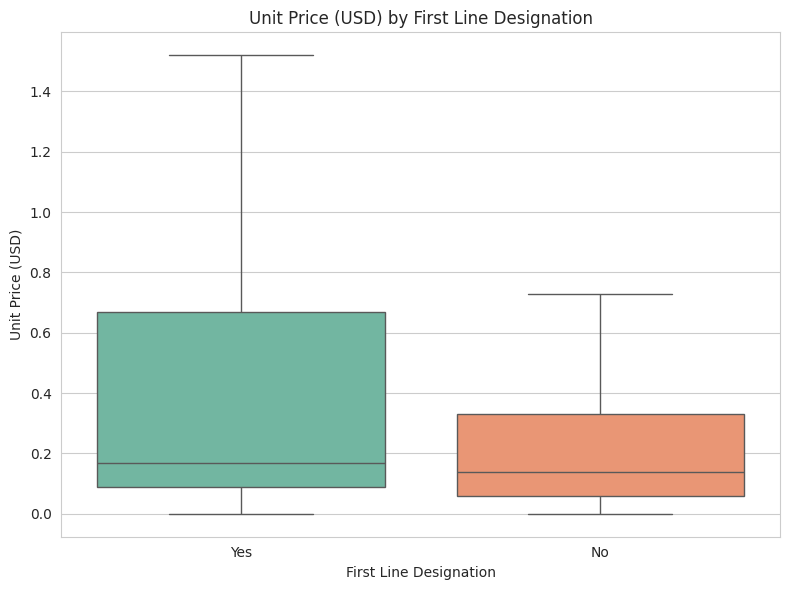

In [26]:
# Chart - 12 visualization code
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='First Line Designation', y='Unit Price',
            hue='First Line Designation', palette='Set2', showfliers=False, legend=False)
plt.title('Unit Price (USD) by First Line Designation')
plt.xlabel('First Line Designation')
plt.ylabel('Unit Price (USD)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A box plot compares the price distribution of first-line vs non-first-line treatments, which is directly relevant to procurement cost planning.

##### 2. What is/are the insight(s) found from the chart?

**First-line designated products have a noticeably higher average unit price (≈ $0.76) than non-first-line products (≈ $0.30)**, reflecting that standard first-line regimens, while procured in the largest volumes, are not necessarily the cheapest per-unit option.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** Since first-line drugs are ordered in the highest volumes, even small per-unit price negotiations on these specific products yield outsized total savings — this is a concrete, prioritized target for procurement negotiations.

### 4.3 Bivariate Analysis — Numerical vs Numerical

#### Chart - 13 - Line Item Quantity vs Line Item Value

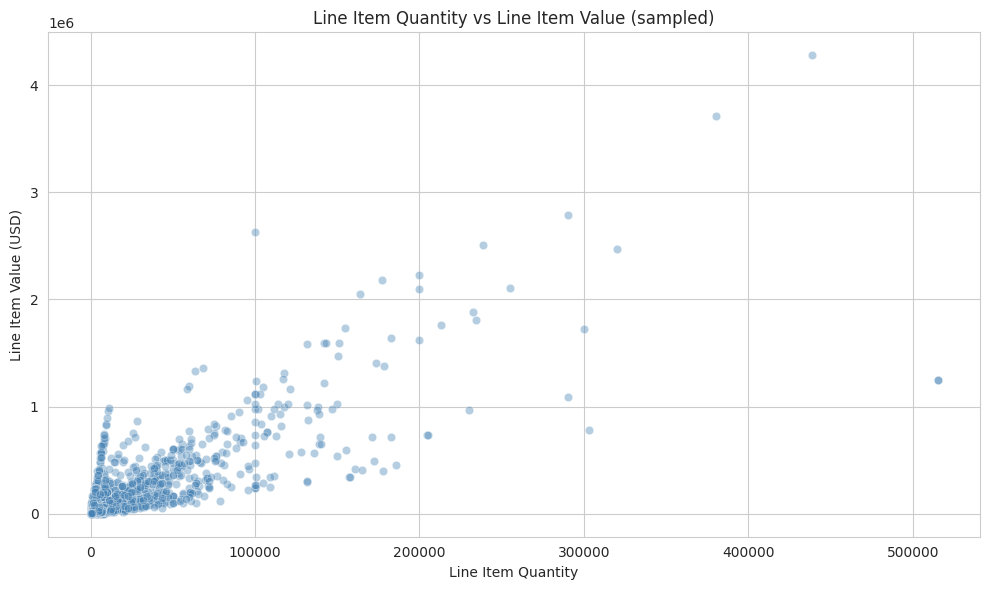

In [27]:
# Chart - 13 visualization code
plt.figure(figsize=(10, 6))
sample = df[['Line Item Quantity', 'Line Item Value']].dropna().sample(
    n=min(2000, df.shape[0]), random_state=42)
sns.scatterplot(data=sample, x='Line Item Quantity', y='Line Item Value', alpha=0.4, color='steelblue')
plt.title('Line Item Quantity vs Line Item Value (sampled)')
plt.xlabel('Line Item Quantity')
plt.ylabel('Line Item Value (USD)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is the most direct way to examine the relationship between two continuous variables (quantity and value), showing both the trend and the spread/outliers.

##### 2. What is/are the insight(s) found from the chart?

There is a **clear positive relationship (correlation ≈ 0.84) between quantity ordered and total line item value** — larger orders cost proportionally more, as expected — but the relationship is not perfectly linear because unit/pack price also varies by product, so the same quantity can translate into very different total values.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** This confirms that value-based forecasting can reasonably use quantity as a leading indicator, but pricing negotiations should still be handled per-product since price-per-unit varies significantly and is not captured by quantity alone.

#### Chart - 14 - Weight (Kg) vs Freight Cost (USD)

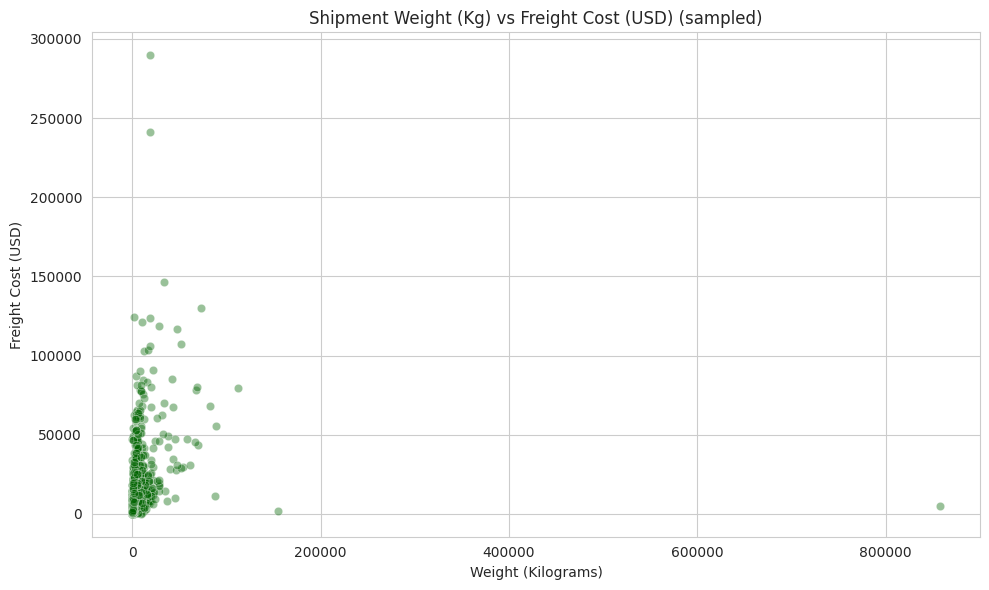

In [28]:
# Chart - 14 visualization code
plt.figure(figsize=(10, 6))
sample = df[['Weight (Kilograms)', 'Freight Cost (USD)']].dropna().sample(
    n=min(2000, df.dropna(subset=['Weight (Kilograms)','Freight Cost (USD)']).shape[0]), random_state=42)
sns.scatterplot(data=sample, x='Weight (Kilograms)', y='Freight Cost (USD)', alpha=0.4, color='darkgreen')
plt.title('Shipment Weight (Kg) vs Freight Cost (USD) (sampled)')
plt.xlabel('Weight (Kilograms)')
plt.ylabel('Freight Cost (USD)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot tests the intuitive assumption that heavier shipments cost more to freight, and reveals how noisy/weak or strong that relationship actually is.

##### 2. What is/are the insight(s) found from the chart?

The relationship is **positive but only moderate (correlation ≈ 0.23)** — heavier shipments do tend to cost more, but weight alone explains relatively little of the variation in freight cost, since shipment mode, distance/country, and INCO term also strongly influence the final freight cost.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** Because weight alone is a weak predictor of freight cost, FedEx Logistics should not rely on weight-based freight estimates alone; freight-cost models and vendor negotiations should also account for shipment mode and destination, which this EDA shows matter just as much or more.

#### Chart - 15 - Line Item Value vs Freight Cost

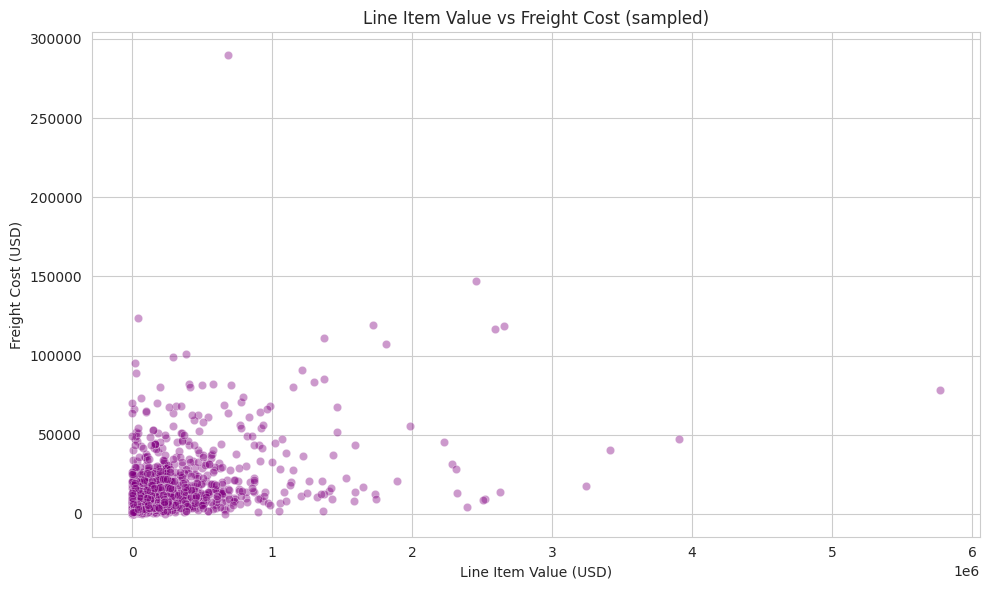

In [29]:
# Chart - 15 visualization code
plt.figure(figsize=(10, 6))
sample = df[['Line Item Value', 'Freight Cost (USD)']].dropna().sample(
    n=min(2000, df.dropna(subset=['Line Item Value','Freight Cost (USD)']).shape[0]), random_state=42)
sns.scatterplot(data=sample, x='Line Item Value', y='Freight Cost (USD)', alpha=0.4, color='purple')
plt.title('Line Item Value vs Freight Cost (sampled)')
plt.xlabel('Line Item Value (USD)')
plt.ylabel('Freight Cost (USD)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot between order value and freight cost helps assess whether more valuable orders proportionally cost more to ship, which is relevant to cost-as-percentage-of-value planning.

##### 2. What is/are the insight(s) found from the chart?

There is a **moderate positive correlation (≈ 0.43) between line item value and freight cost** — larger, more valuable orders do tend to have higher freight cost, but with substantial scatter, again reinforcing that freight cost is driven by multiple factors (mode, distance) beyond order value alone.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** This supports building a freight-cost-as-percentage-of-order-value KPI for monitoring, but flags that any freight cost forecasting model needs to include shipment mode and destination as additional features rather than relying on order value alone.

### 4.4 Bivariate Analysis — Categorical vs Categorical

#### Chart - 16 - On-Time vs Late Delivery Rate by Shipment Mode

<Figure size 1000x600 with 0 Axes>

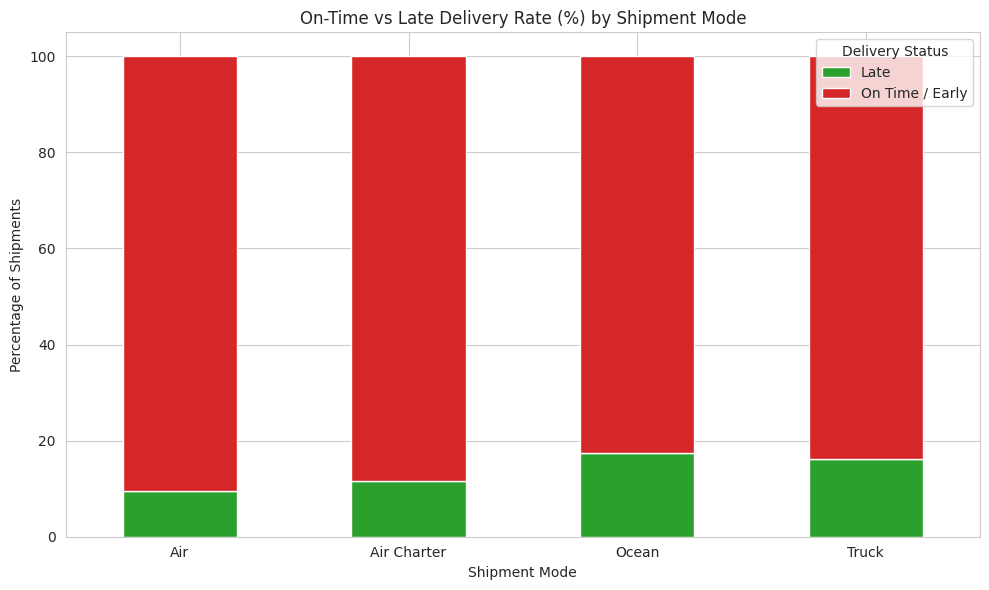

In [30]:
# Chart - 16 visualization code
plt.figure(figsize=(10, 6))
ontime_mode = pd.crosstab(df['Shipment Mode'], df['On Time Delivery'], normalize='index') * 100
ontime_mode.plot(kind='bar', stacked=True, color=['#2ca02c', '#d62728'], figsize=(10, 6))
plt.title('On-Time vs Late Delivery Rate (%) by Shipment Mode')
plt.xlabel('Shipment Mode')
plt.ylabel('Percentage of Shipments')
plt.xticks(rotation=0)
plt.legend(title='Delivery Status')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A stacked percentage bar chart is ideal for comparing the proportional split of a binary outcome (on-time vs late) across categories (shipment mode), normalizing away differences in raw shipment counts — a categorical-vs-categorical relationship.

##### 2. What is/are the insight(s) found from the chart?

**Air Charter and Truck shipments show the best on-time performance** while **Ocean shipments have the highest late-delivery rate**, consistent with the numeric delay findings in Chart 9 but expressed here as a clear proportional comparison.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** This reinforces mode-selection guidance: prioritize Air Charter/Truck for time-critical shipments and build extra schedule buffer wherever Ocean is used for cost reasons.

#### Chart - 17 - Shipment Mode vs Product Group (Heatmap of Counts)

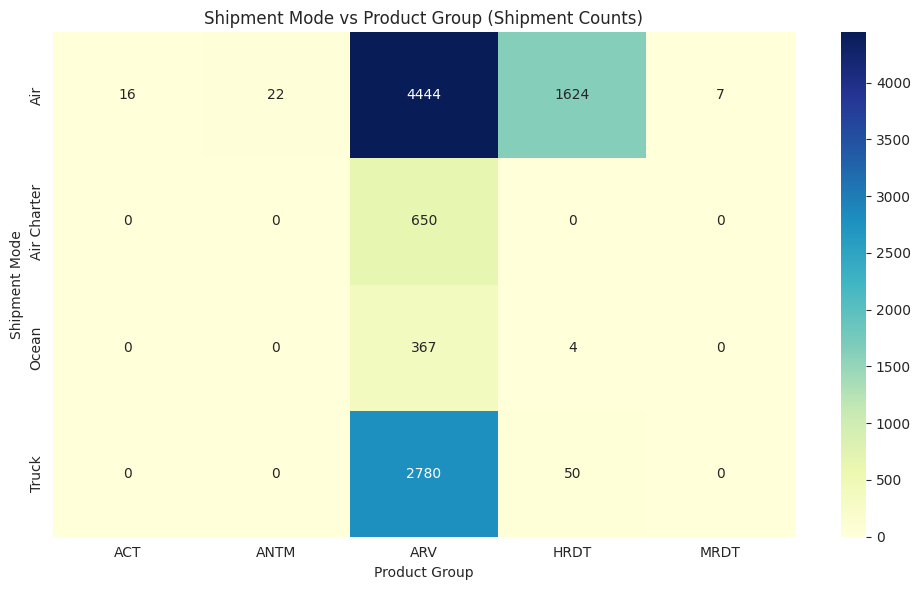

In [31]:
# Chart - 17 visualization code
plt.figure(figsize=(10, 6))
mode_pg_ct = pd.crosstab(df['Shipment Mode'], df['Product Group'])
sns.heatmap(mode_pg_ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Shipment Mode vs Product Group (Shipment Counts)')
plt.xlabel('Product Group')
plt.ylabel('Shipment Mode')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap of a cross-tabulation is the most compact way to show the joint frequency of two categorical variables (Shipment Mode and Product Group) and immediately reveals which combinations dominate.

##### 2. What is/are the insight(s) found from the chart?

**ARV shipments dominate every shipment mode**, but notably **Air Charter and Ocean are used exclusively for ARV** (0 HRDT/ACT/ANTM/MRDT shipments via these modes) — HRDT test kits and other product groups move almost entirely via **Air** and some **Truck**, never via Charter or Ocean, suggesting these lighter, more time-sensitive diagnostic products don't need or use bulk-shipment modes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** This confirms that Air Charter/Ocean cost-optimization efforts should focus purely on the ARV product line (since that's the only line using these modes), while HRDT logistics optimization should focus on standard Air/Truck efficiency instead.

#### Chart - 18 - Fulfill Via vs First Line Designation

<Figure size 800x600 with 0 Axes>

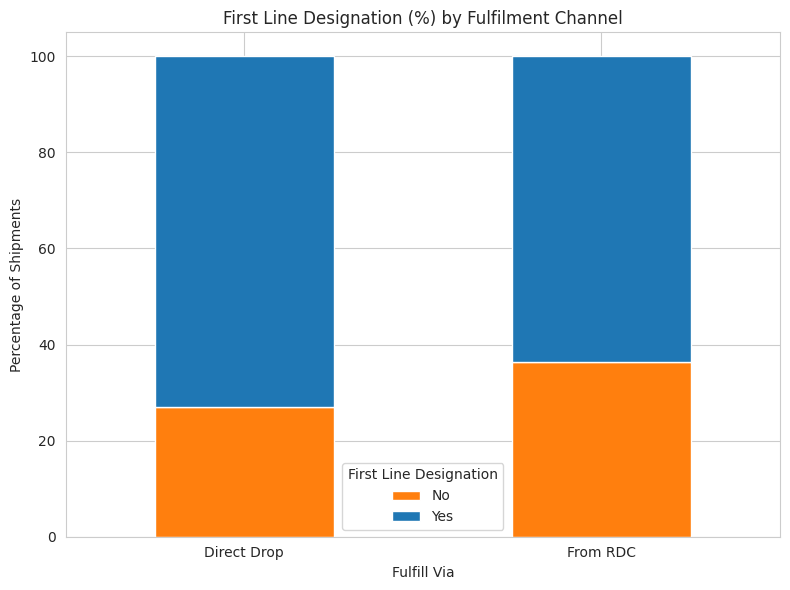

In [32]:
# Chart - 18 visualization code
plt.figure(figsize=(8, 6))
fulfill_fl = pd.crosstab(df['Fulfill Via'], df['First Line Designation'], normalize='index') * 100
fulfill_fl.plot(kind='bar', stacked=True, color=['#ff7f0e', '#1f77b4'], figsize=(8, 6))
plt.title('First Line Designation (%) by Fulfilment Channel')
plt.xlabel('Fulfill Via')
plt.ylabel('Percentage of Shipments')
plt.xticks(rotation=0)
plt.legend(title='First Line Designation')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A stacked percentage bar chart compares the proportional composition of a second categorical variable (First Line Designation) across the two fulfilment channels (From RDC vs Direct Drop).

##### 2. What is/are the insight(s) found from the chart?

**Direct Drop shipments are more heavily first-line (≈ 73%) compared to From-RDC shipments (≈ 64%)**, suggesting that direct vendor-to-client shipments are more often used for standard, high-priority first-line treatment regimens, while RDC-fulfilled shipments carry a somewhat higher share of non-first-line/alternative regimens.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** Since Direct Drop shipments skew toward first-line drugs (the highest-volume, most critical products), ensuring Direct Drop lanes are reliable and fast should be a top operational priority.

### 4.5 Multivariate Analysis

#### Chart - 19 - Correlation Heatmap

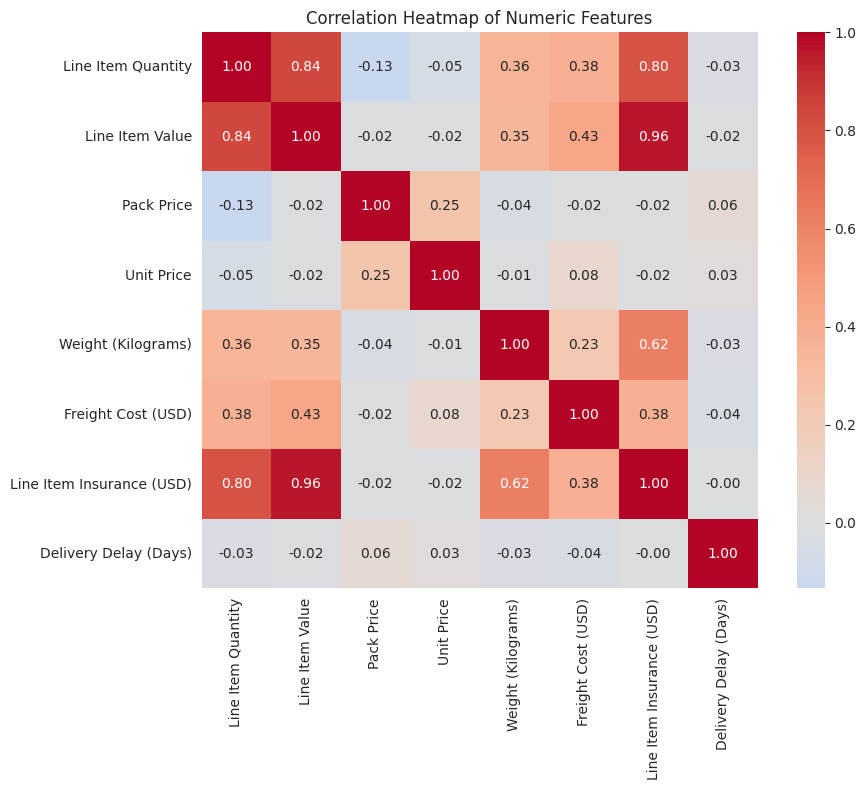

In [33]:
# Correlation Heatmap visualization code
plt.figure(figsize=(10, 8))
numeric_cols = ['Line Item Quantity', 'Line Item Value', 'Pack Price', 'Unit Price',
                'Weight (Kilograms)', 'Freight Cost (USD)', 'Line Item Insurance (USD)',
                'Delivery Delay (Days)']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to summarize pairwise linear relationships between many numeric variables at once (a multivariate view), making it easy to spot strong positive/negative correlations that deserve deeper investigation.

##### 2. What is/are the insight(s) found from the chart?

**`Line Item Value` is strongly positively correlated with `Line Item Insurance (USD)` (≈0.96)** and moderately correlated with `Line Item Quantity` (≈0.84), which makes intuitive sense — insurance cost and quantity scale with the value being shipped. `Freight Cost` and `Weight` show a moderate positive correlation with quantity and value (≈0.23–0.43, matching Charts 14–15), but the relationship is weaker and noisier, reflecting that freight cost depends on many other factors (mode, distance, INCO term) beyond just quantity/weight. `Delivery Delay (Days)` shows very weak correlation with all the pricing/quantity variables, confirming that **delay is driven mainly by categorical/operational factors (mode, country, vendor) rather than order size**.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** The weak correlation between order size and delivery delay is reassuring — it means large, high-value orders are not inherently more likely to be late, so growing the program's order sizes should not, by itself, degrade delivery performance. It also confirms freight-cost models need multiple features (not just weight/value) to be accurate.

#### Chart - 20 - Pair Plot

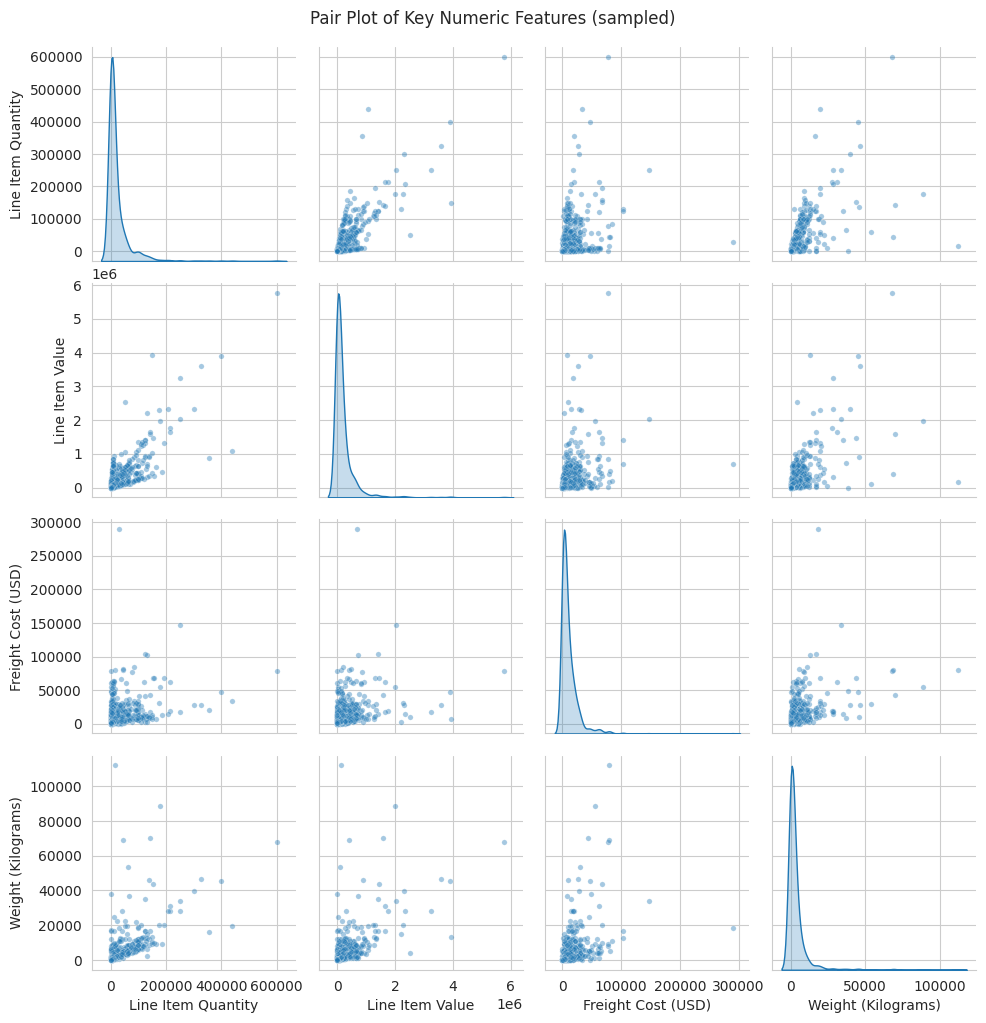

In [34]:
# Pair Plot visualization code
pairplot_cols = ['Line Item Quantity', 'Line Item Value', 'Freight Cost (USD)', 'Weight (Kilograms)']
sample_df = df[pairplot_cols].dropna().sample(n=min(1000, df[pairplot_cols].dropna().shape[0]), random_state=42)
sns.pairplot(sample_df, diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle('Pair Plot of Key Numeric Features (sampled)', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot gives a compact grid of all pairwise scatter plots (plus univariate distributions on the diagonal) for several key numeric features in one figure — a multivariate view that lets us visually validate the linear correlations seen in the heatmap and spot any non-linear patterns or outliers. A 1,000-row random sample is used to keep the plot readable and fast to render given the dataset size.

##### 2. What is/are the insight(s) found from the chart?

The scatter plots confirm a **positive, somewhat noisy relationship between `Line Item Quantity`, `Line Item Value`, `Weight` and `Freight Cost`**, with most points clustered near the origin (many small/medium orders) and a sparse tail of very large orders extending outward — consistent with the right-skewed distributions seen earlier. No unexpected non-linear or inverse relationships are visible.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** Confirming there are no hidden non-linear traps in these relationships means simple linear cost-estimation heuristics (e.g. cost roughly scales with order size) remain reasonable starting points for budgeting, while still needing the categorical factors (mode, country) identified elsewhere for precision.

#### Chart - 21 - Average Freight Cost by Shipment Mode and Product Group

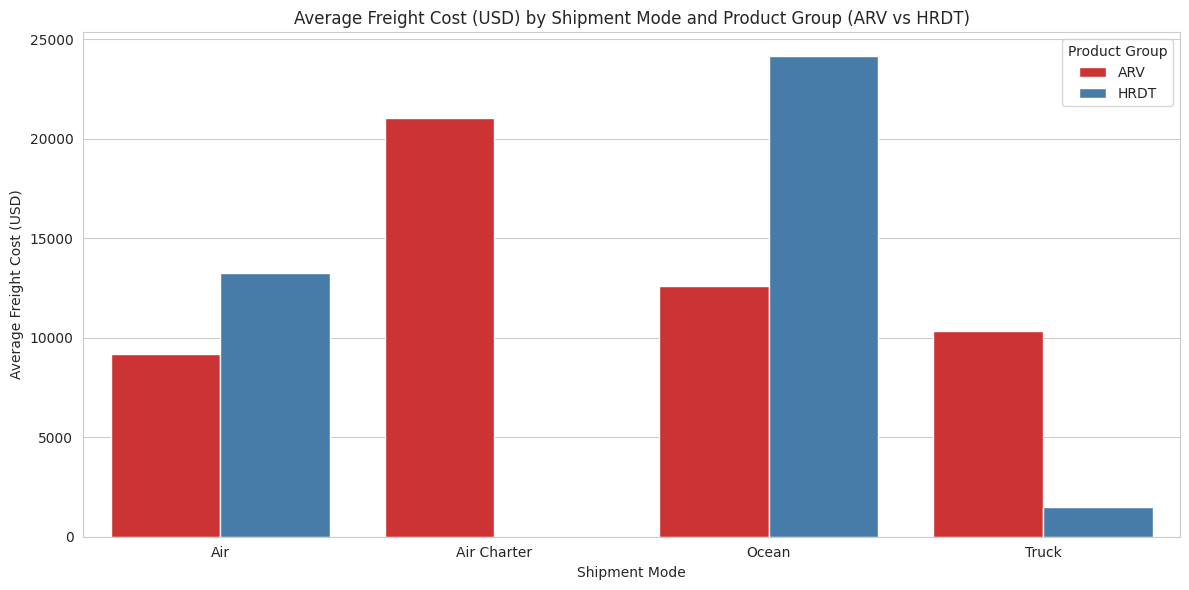

In [35]:
# Chart - 21 visualization code (multivariate: numeric x 2 categoricals)
plt.figure(figsize=(12, 6))
main_groups = df[df['Product Group'].isin(['ARV', 'HRDT'])]
avg_freight_multi = (main_groups.groupby(['Shipment Mode', 'Product Group'])['Freight Cost (USD)']
                      .mean().reset_index())
sns.barplot(data=avg_freight_multi, x='Shipment Mode', y='Freight Cost (USD)', hue='Product Group',
            palette='Set1')
plt.title('Average Freight Cost (USD) by Shipment Mode and Product Group (ARV vs HRDT)')
plt.xlabel('Shipment Mode')
plt.ylabel('Average Freight Cost (USD)')
plt.legend(title='Product Group')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart lets us examine how a numeric outcome (average freight cost) varies jointly across two categorical dimensions (Shipment Mode and Product Group) simultaneously — a genuinely multivariate comparison beyond the single-factor views shown earlier.

##### 2. What is/are the insight(s) found from the chart?

Average freight cost for **Air** shipments differs between ARV and HRDT product groups, and since Air Charter/Ocean carry ARV exclusively (per Chart 17), the comparison is only meaningful for the Air/Truck modes where both product groups are shipped — within those, freight cost per shipment mode is fairly consistent regardless of product group, suggesting **shipment mode, not product type, is the primary freight-cost driver** for a given lane.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** Since shipment mode (not product group) is the dominant freight-cost lever, cost-reduction efforts should focus on mode selection and carrier negotiation rather than trying to redesign product-specific packaging/shipping processes.

#### Chart - 22 - Shipment Volume Over Time by Product Group

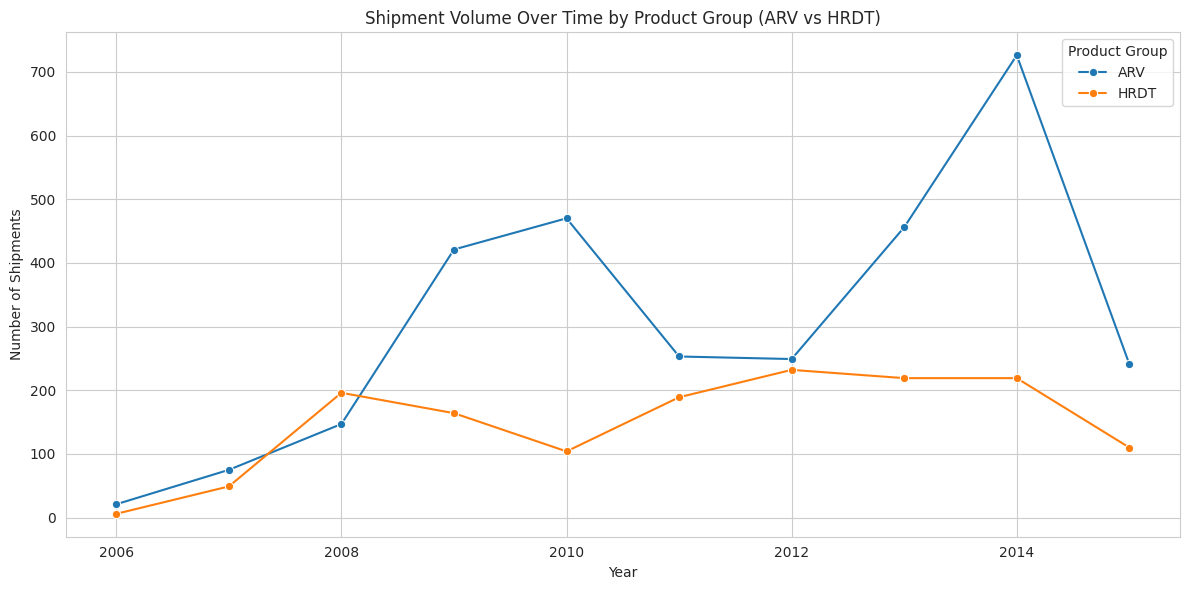

In [36]:
# Chart - 22 visualization code (multivariate: time x category x count)
plt.figure(figsize=(12, 6))
yearly_pg = (df[df['Product Group'].isin(['ARV', 'HRDT'])]
             .groupby(['Order Year', 'Product Group']).size().reset_index(name='Shipment Count'))
sns.lineplot(data=yearly_pg, x='Order Year', y='Shipment Count', hue='Product Group', marker='o')
plt.title('Shipment Volume Over Time by Product Group (ARV vs HRDT)')
plt.xlabel('Year')
plt.ylabel('Number of Shipments')
plt.legend(title='Product Group')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A multi-line time series lets us compare how shipment volume trends over time differ across product groups simultaneously (time + category + count = three dimensions in one chart), revealing whether growth is uniform or concentrated in one product line.

##### 2. What is/are the insight(s) found from the chart?

**ARV shipment volume tracks the overall growth trend seen in Chart 6** (rising steadily to a 2014 peak), while **HRDT (diagnostic test) shipment volume grew later and more sharply**, reflecting the program's expansion into HIV testing/screening in the later years of the 2006–2015 window, on top of its original treatment-focused mandate.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes.** Recognizing that HRDT is a newer, faster-growing line means FedEx Logistics should plan for continued growth in diagnostic-kit logistics specifically (different weight/packaging profile than ARV drugs) rather than assuming all future growth will look like historical ARV growth.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the EDA (22 charts across univariate, bivariate, and multivariate analysis), the following data-driven recommendations are suggested to **FedEx Logistics / SCMS**:

1. **Optimize shipment mode selection.** Air Charter is the most expensive mode (~$21K average freight cost) but also fastest; Ocean is comparatively slow (average +5.9 days late) despite not being the cheapest. For non-urgent, high-volume shipments, shift more volume to Truck or standard Air, and reserve Air Charter strictly for time-critical/emergency orders, to cut freight spend without harming patient outcomes.
2. **Target the highest-volume, highest-freight-cost country corridors** (Chart 11) for carrier contract renegotiation and shipment consolidation, since even small per-shipment savings compound quickly at high volume.
3. **Diversify vendor and manufacturing-site base.** A handful of vendors (Aurobindo, Mylan, Hetero, Cipla) and mostly India-based manufacturing sites supply the large majority of volume. Qualify and maintain backup vendors/sites in different geographies to reduce single-point-of-failure risk to the ARV supply chain.
4. **Investigate and reduce late-delivery tail risk.** While 88.5% of shipments are on-time/early, the long tail of severely late shipments (100+ days), concentrated in Ocean shipments (Charts 9, 16), should be root-caused by country/vendor combination and addressed with tighter SLAs or buffer stock in the affected corridors.
5. **Renegotiate INCO terms** where FedEx/SCMS currently bears the most logistics burden (EXW terms), moving toward more DDP/CIP arrangements with key vendors where it reduces total landed cost and risk.
6. **Build multi-feature freight-cost models.** Since freight cost correlates only moderately with weight (r≈0.23) and value (r≈0.43) but strongly with shipment mode (Chart 21), any cost-forecasting or budgeting tool should include mode and destination as primary features, not just order size.
7. **Plan capacity for HRDT growth separately from ARV.** Chart 22 shows HRDT (diagnostic test kits) is a newer, faster-growing line with a different logistics profile — dedicated planning avoids treating it as a scaled copy of ARV logistics.
8. **Prioritize ARV and HRDT product lines** (>99% of volume) in all of the above initiatives, since improvements here have the largest overall impact on program cost and delivery performance.

# **Conclusion**

This EDA of the SCMS Delivery History Dataset — covering **22 charts across univariate, bivariate (numerical-categorical, numerical-numerical, categorical-categorical), and multivariate analysis** — revealed a large (10,324-shipment), predominantly ARV/HIV-testing supply chain spanning 2006–2015 and 40+ countries, worth roughly **$1.63 billion** in total shipment value. Key findings include:

- **Delivery performance is strong overall (88.5% on-time/early)**, but a meaningful tail of shipments experiences severe delays, concentrated in Ocean shipments and certain countries/vendors.
- **Air is the dominant shipment mode**, and **Air Charter, while fastest, is by far the most expensive**, representing a clear cost-vs-speed trade-off that can be actively managed. Shipment mode — not product group or order size — is the primary driver of freight cost (Chart 21).
- **Shipment volume grew substantially from 2006 to 2014**, with the newer HRDT (diagnostic) product line growing faster than ARV in later years, which should inform future capacity planning.
- **Vendor and manufacturing-site concentration** (Aurobindo, Mylan, Hetero, Cipla; predominantly India-based sites) is efficient for cost but introduces supply-chain risk that warrants diversification.
- **Order size (quantity/value) correlates strongly with each other (r≈0.84) but only weakly with delivery delay**, and only moderately with freight cost (r≈0.23–0.43), meaning growth in order volume need not come at the cost of delivery reliability, and freight-cost models need more than just order size to be accurate.

Acting on these insights — optimizing shipment-mode mix, targeting high-cost corridors, diversifying vendors, building multi-feature cost models, and addressing tail-risk delays — can help FedEx Logistics reduce freight costs and improve delivery reliability for this critical, life-saving supply chain.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***